In [16]:
# IPython magic commands
%load_ext autoreload
%autoreload 2

# Standard library imports
import os
from pathlib import Path

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

# Custom utilities imports
from data_io_utils import load_data_from_parquet, save_all_experiment_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Definitions

In [2]:
data_dir = Path("/ceph/aeon/aeon/code/scratchpad/methods_paper_data")
save_dir = Path("/ceph/aeon/aeon/code/scratchpad/anaya/rl_modelling_results")
os.makedirs(data_dir, exist_ok=True)
os.makedirs(save_dir, exist_ok=True)
cm2px = 5.2  # 1 cm = 5.2 px roughly in aeon arenas
light_off, light_on = 7, 20  # 7am to 7pm
fps = 50

In [3]:
experiments = [
    {"name": "social0.2-aeon3", "presocial_start": '2024-01-31 11:00:00', "presocial_end": '2024-02-08 15:00:00', "social_start": '2024-02-09 16:00:00', "social_end": '2024-02-23 13:00:00', "postsocial_start": '2024-02-25 17:00:00', "postsocial_end": '2024-03-02 14:00:00'},
    {"name": "social0.2-aeon4", "presocial_start": '2024-01-31 11:00:00', "presocial_end": '2024-02-08 15:00:00', "social_start": '2024-02-09 17:00:00', "social_end": '2024-02-23 12:00:00', "postsocial_start": '2024-02-25 18:00:00', "postsocial_end": '2024-03-02 13:00:00'},
    {"name": "social0.3-aeon3", "presocial_start": '2024-06-08 19:00:00', "presocial_end": '2024-06-17 13:00:00', "social_start": '2024-06-25 11:00:00', "social_end": '2024-07-06 13:00:00', "postsocial_start": '2024-07-07 16:00:00', "postsocial_end": '2024-07-14 14:00:00'},
    {"name": "social0.3-aeon4", "presocial_start": '2024-06-08 19:00:00', "presocial_end": '2024-06-17 14:00:00', "social_start": '2024-06-19 12:00:00', "social_end": '2024-07-03 14:00:00', "postsocial_start": '2024-07-04 11:00:00', "postsocial_end": '2024-07-13 12:00:00'},
    {"name": "social0.4-aeon3", "presocial_start": '2024-08-16 17:00:00', "presocial_end": '2024-08-24 10:00:00', "social_start": '2024-08-28 11:00:00', "social_end": '2024-09-09 13:00:00', "postsocial_start": '2024-09-09 18:00:00', "postsocial_end": '2024-09-22 16:00:00'},
    {"name": "social0.4-aeon4", "presocial_start": '2024-08-16 15:00:00', "presocial_end": '2024-08-24 10:00:00', "social_start": '2024-08-28 10:00:00', "social_end": '2024-09-09 01:00:00', "postsocial_start": '2024-09-09 15:00:00', "postsocial_end": '2024-09-22 16:00:00'}
]
experiment = experiments[0]

In [4]:
def load_experiment_data(
    data_dir: str,
    experiment: dict | None = None,
    periods: list | None = None,
    data_types: list[str] = ['rfid', 'position'],
    trim_days: int | None = None
) -> dict:
    """
    Load all data types for specified periods of an experiment.
    
    Parameters:
    - experiment: experiment dict with period start/end times
    - periods: list of periods to load
    - data_types: list of data types to load
    - data_dir: directory containing data files
    - trim_days: Optional number of days to trim from start (None = no trim)
    
    Returns:
    - Dictionary containing dataframes for each period/data type combination
    """
    
    result = {}

    if periods is None:
        periods = [None]
    
    for period in periods:
        for data_type in data_types:
            print(f"Loading {period} {data_type} data...")
            
            # Load data
            if experiment is not None:
                experiment_name = experiment["name"]
            else:
                experiment_name = None
            df = load_data_from_parquet(
                experiment_name=experiment_name,
                period=period,
                data_type=data_type,
                data_dir=data_dir,
                set_time_index=(data_type == 'position')
            )
            
            # Trim if requested
            if trim_days is not None and len(df) > 0:
                if data_type == 'rfid':
                    start_time = df['chunk_start'].min()
                    end_time = start_time + pd.Timedelta(days=trim_days)
                    df = df[df['chunk_start'] < end_time]
                if data_type == 'foraging':
                    start_time = df['start'].min()
                    end_time = start_time + pd.Timedelta(days=trim_days)
                    df = df[df['start'] < end_time]
                if data_type == 'position':
                    start_time = df.index.min()
                    end_time = start_time + pd.Timedelta(days=trim_days)
                    df = df.loc[df.index < end_time]
                
                print(f"  Trimmed to {trim_days} days: {len(df)} records")
            
            # Store in result
            key = f"{period}_{data_type}"
            result[key] = df
            
            # For position data, handle duplicates
            if data_type == 'position' and len(df) > 0:
                original_len = len(df)
                df = df.reset_index()
                df = df.drop_duplicates(subset=['time', 'identity_name'])
                df = df.set_index('time')
                result[key] = df
                if len(df) < original_len:
                    print(f"  Removed duplicates: {original_len} -> {len(df)}")
    
    return result

# Load and prepare data

In [5]:
# def format_size(size):
#     """Convert bytes to human readable format"""
#     for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
#         if size < 1024.0:
#             return f"{size:.2f} {unit}"
#         size /= 1024.0
#     return f"{size:.2f} PB"

# files = [f for f in data_dir.iterdir() if "social0.2-aeon4_presocial" in f.name]
# for file in files:
#     size = file.stat().st_size
#     print(f"{file.name}: {format_size(size)}")

# print("---")
# base_dir = Path("/ceph/aeon/aeon/code/scratchpad/methods_paper_data.*")
# files = [f for f in base_dir.iterdir() if "position" in f.name]
# for file in files:
#     size = file.stat().st_size
#     print(f"{file.name}: {format_size(size)}")

In [6]:
data = load_experiment_data(
    experiment=experiment,
    data_dir=data_dir,
    periods=['social'],
    data_types=["patchinfo", "positiondenoised"]
)

social_patchinfo_df = data['social_patchinfo']
social_position_df = data['social_positiondenoised']
social_position_df.set_index('time', inplace=True)
social_position_df.sort_index(inplace=True)

Loading social patchinfo data...
Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.2-aeon3_social_patchinfo.parquet...
  Loaded 486 rows
Combined data: 486 rows
Loading social positiondenoised data...
Found 1 matching files
Loading /ceph/aeon/aeon/code/scratchpad/methods_paper_data/social0.2-aeon3_social_positiondenoised.parquet...
  Loaded 100308812 rows
Combined data: 100308812 rows


In [ ]:
"""Find unique patch configurations and their counts"""

# Group by block_start and aggregate patch_name and patch_rate combinations
config_df = social_patchinfo_df.groupby('block_start').apply(
    lambda x: tuple(sorted(zip(x['patch_name'], x['patch_rate']), key=lambda item: item[0])),
    include_groups=False
).reset_index(name='config')

# Count occurrences and sort by patch rates
config_counts = config_df['config'].value_counts().sort_index(
    key=lambda idx: idx.map(lambda x: (x[0][1], x[1][1], x[2][1]))
)
n_configs = len(config_counts)

# Create numbered mapping and add to dataframe
config_mapping = {config: i+1 for i, config in enumerate(config_counts.index)}
config_df['config_num'] = config_df['config'].map(config_mapping)

# Display results
print(f"Number of unique configs: {n_configs}\n")
print("Config#  Count  Patch1   Patch2   Patch3")
print("-" * 45)
for config, count in config_counts.items():
    rates = [f"{rate:.4f}" for _, rate in config]
    print(f"  {config_mapping[config]:2d}     {count:2d}    {rates[0]}   {rates[1]}   {rates[2]}")

display(config_df)

Number of unique configs: 8

Config#  Count  Patch1   Patch2   Patch3
---------------------------------------------
   1     21    0.0020   0.0020   0.0020
   2     24    0.0020   0.0033   0.0100
   3     14    0.0020   0.0100   0.0033
   4     23    0.0033   0.0020   0.0100
   5     22    0.0033   0.0100   0.0020
   6     23    0.0100   0.0020   0.0033
   7     18    0.0100   0.0033   0.0020
   8     17    0.0100   0.0100   0.0100


,block_start,config,config_num
0,2024-02-09 16:08:29.004000,"((Patch1, 0.0033), (Patch2, 0.002), (Patch3, 0...",4
1,2024-02-09 16:23:03.001984,"((Patch1, 0.002), (Patch2, 0.01), (Patch3, 0.0...",3
2,2024-02-09 17:44:52.000000,"((Patch1, 0.002), (Patch2, 0.002), (Patch3, 0....",1
3,2024-02-09 20:35:49.020000,"((Patch1, 0.0033), (Patch2, 0.01), (Patch3, 0....",5
4,2024-02-09 22:31:13.001984,"((Patch1, 0.01), (Patch2, 0.002), (Patch3, 0.0...",6
...,...,...,...
157,2024-02-23 02:23:24.004000,"((Patch1, 0.01), (Patch2, 0.002), (Patch3, 0.0...",6
158,2024-02-23 04:27:02.001984,"((Patch1, 0.002), (Patch2, 0.01), (Patch3, 0.0...",3
159,2024-02-23 06:01:18.001984,"((Patch1, 0.002), (Patch2, 0.002), (Patch3, 0....",1
160,2024-02-23 08:24:51.005984,"((Patch1, 0.002), (Patch2, 0.0033), (Patch3, 0...",2


In [8]:
"""Add block_start and config_num to social_position_df"""

# Merge config_num and block_start based on block_start times
merge_result = pd.merge_asof(
    social_position_df.reset_index()[['time']],
    config_df[['block_start', 'config_num']].sort_values('block_start'),
    left_on='time',
    right_on='block_start',
    direction='backward'
)

social_position_df['config_num']   = merge_result['config_num'].values
social_position_df['block_start']  = merge_result['block_start'].values

display(social_position_df)

,experiment_name,identity_name,identity_likelihood,x,y,likelihood,period,config_num,block_start
time,,,,,,,,,
2024-02-09 16:18:42.540,social0.2-aeon3,BAA-1104045,NaN,1280.354370,482.962128,0.453161,social,4,2024-02-09 16:08:29.004000
2024-02-09 16:18:42.540,social0.2-aeon3,BAA-1104047,0.943744,394.939392,101.911224,0.453161,social,4,2024-02-09 16:08:29.004000
2024-02-09 16:18:42.560,social0.2-aeon3,BAA-1104047,0.800716,397.828003,107.254784,0.742750,social,4,2024-02-09 16:08:29.004000
2024-02-09 16:18:42.560,social0.2-aeon3,BAA-1104045,NaN,1280.343140,482.962860,0.742750,social,4,2024-02-09 16:08:29.004000
2024-02-09 16:18:42.580,social0.2-aeon3,BAA-1104047,0.964355,400.513672,114.881218,0.778326,social,4,2024-02-09 16:08:29.004000
...,...,...,...,...,...,...,...,...,...
2024-02-23 12:05:30.720,social0.2-aeon3,BAA-1104047,NaN,678.007568,69.745773,0.795622,social,3,2024-02-23 09:58:52.005984
2024-02-23 12:05:30.740,social0.2-aeon3,BAA-1104047,NaN,677.728638,56.752686,0.803144,social,3,2024-02-23 09:58:52.005984
2024-02-23 12:05:30.760,social0.2-aeon3,BAA-1104047,NaN,675.079102,45.916546,0.324165,social,3,2024-02-23 09:58:52.005984


In [9]:
"""Make state df"""

# Choose focal mouse (0 or 1)
focal_identity = social_position_df['identity_name'].unique()[0]  # or [1]

# Split into self and other, keeping only what we need (include time + context)
self_df = social_position_df[social_position_df['identity_name'] == focal_identity]\
    .reset_index()[['time', 'experiment_name', 'block_start', 'config_num', 'x', 'y']]\
    .rename(columns={'x': 'x_self', 'y': 'y_self'})

other_df = social_position_df[social_position_df['identity_name'] != focal_identity]\
    .reset_index()[['time', 'experiment_name', 'block_start', 'x', 'y']]\
    .rename(columns={'x': 'x_other', 'y': 'y_other'})

# Exact merge on time + experiment + block (no asof, no tolerance)
state_df = self_df.merge(
    other_df,
    on=['time', 'experiment_name', 'block_start'],
    how='inner'
)

# Add velocities (finite differences within each experiment/block)
dt = 1.0 / fps
state_df[['vx_self', 'vy_self']] = state_df.groupby(
    ['experiment_name', 'block_start']
)[['x_self', 'y_self']].diff() / dt
state_df[['vx_other', 'vy_other']] = state_df.groupby(
    ['experiment_name', 'block_start']
)[['x_other', 'y_other']].diff() / dt

# Relative position and velocity (other - self)
state_df['dx']  = state_df['x_other'] - state_df['x_self']
state_df['dy']  = state_df['y_other'] - state_df['y_self']
state_df['dvx'] = state_df['vx_other'] - state_df['vx_self']
state_df['dvy'] = state_df['vy_other'] - state_df['vy_self']

# Drop the first frame of each block where velocities are NaN
state_df = state_df.dropna(subset=['vx_self', 'vy_self', 'vx_other', 'vy_other'])

display(state_df)

,time,experiment_name,block_start,config_num,x_self,y_self,x_other,y_other,vx_self,vy_self,vx_other,vy_other,dx,dy,dvx,dvy
1,2024-02-09 16:18:42.560,social0.2-aeon3,2024-02-09 16:08:29.004000,4,1280.343140,482.962860,397.828003,107.254784,-0.561523,0.036621,144.430542,267.177963,-882.515137,-375.708076,144.992065,267.141342
2,2024-02-09 16:18:42.580,social0.2-aeon3,2024-02-09 16:08:29.004000,4,1280.333862,482.957886,400.513672,114.881218,-0.463867,-0.248718,134.283447,381.321716,-879.820190,-368.076668,134.747314,381.570435
3,2024-02-09 16:18:42.600,social0.2-aeon3,2024-02-09 16:08:29.004000,4,1280.336426,482.968201,402.865906,120.324570,0.128174,0.515747,117.611694,272.167587,-877.470520,-362.643631,117.483521,271.651840
4,2024-02-09 16:18:42.620,social0.2-aeon3,2024-02-09 16:08:29.004000,4,408.271576,123.213463,382.078827,120.154724,-43603.242493,-17987.736893,-1039.353943,-8.492279,-26.192749,-3.058739,42563.888550,17979.244614
5,2024-02-09 16:18:42.640,social0.2-aeon3,2024-02-09 16:08:29.004000,4,410.786255,130.853119,386.991028,125.641502,125.733948,381.982803,245.610046,274.338913,-23.795227,-5.211617,119.876099,-107.643890
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46639125,2024-02-23 12:05:23.780,social0.2-aeon3,2024-02-23 09:58:52.005984,3,757.736816,200.463379,752.750122,200.525452,-2540.832520,9319.663143,-2270.770264,4950.985718,-4.986694,0.062073,270.062256,-4368.677425
46639126,2024-02-23 12:05:28.240,social0.2-aeon3,2024-02-23 09:58:52.005984,3,813.608826,88.194351,722.763550,51.283493,2793.600464,-5613.451385,-1499.328613,-7462.097931,-90.845276,-36.910858,-4292.929077,-1848.646545
46639127,2024-02-23 12:05:28.260,social0.2-aeon3,2024-02-23 09:58:52.005984,3,819.173767,80.296646,723.110046,48.486946,278.247070,-394.885254,17.324829,-139.827347,-96.063721,-31.809700,-260.922241,255.057907
46639128,2024-02-23 12:05:28.280,social0.2-aeon3,2024-02-23 09:58:52.005984,3,824.366638,72.565155,731.048767,32.511383,259.643555,-386.574554,396.936035,-798.778152,-93.317871,-40.053772,137.292480,-412.203598


In [10]:
"""Build transitions (s, a, s_next, done, c) from state_df"""

k = 10  # Δt = 200 ms at 50 Hz

state_cols = ["x_self", "y_self", "vx_self", "vy_self", "dx", "dy", "dvx", "dvy"]

# Index within each block and block length
state_df["block_idx"] = state_df.groupby(["experiment_name", "block_start"]).cumcount()
state_df["block_len"] = state_df.groupby(["experiment_name", "block_start"])["block_idx"].transform("max") + 1

# Next-state columns via k-step shift within each block
group_keys = ["experiment_name", "block_start"]
for col in state_cols:
    state_df[f"{col}_next"] = state_df.groupby(group_keys)[col].shift(-k)

# Keep only rows where a next state exists
mask = state_df["x_self_next"].notna()
trans_df = state_df[mask]

# s_t and s_{t+k}
s = trans_df[state_cols].to_numpy(dtype="float32")
s_next = trans_df[[f"{c}_next" for c in state_cols]].to_numpy(dtype="float32")

# k-step action: displacement of self
a = np.stack([
    trans_df["x_self_next"].values - trans_df["x_self"].values,
    trans_df["y_self_next"].values - trans_df["y_self"].values,
], axis=1).astype("float32")

# done: last valid transition in each block (after which no further k-step exists)
done = (trans_df["block_idx"] + k == trans_df["block_len"] - 1).to_numpy()

# Environment config (config_num at time t)
c = trans_df["config_num"].to_numpy(dtype="int64")

print("Transitions:", len(s), "  States dim:", s.shape[1], "  Action dim:", a.shape[1])

Transitions: 46637348   States dim: 8   Action dim: 2


In [11]:
"""Fit imitation policy"""

# Check if saved file exists
load = False
save_path = save_dir / "imitation_policy3.pt"
if save_path.exists():
    load = True

# Build phi, a low-dimensional subset of state features most relevant for action selection
phi_cols = ["x_self", "y_self", "dx", "dy"]
phi_s = trans_df[phi_cols].to_numpy(dtype="float32")

# z-score normalise
phi_mean = phi_s.mean(0, keepdims=True)
phi_std  = phi_s.std(0, keepdims=True) + 1e-6
phi_s_norm = (phi_s - phi_mean) / phi_std # [N, 4]
a_mean = a.mean(0, keepdims=True)
a_std  = a.std(0, keepdims=True) + 1e-6
actions_norm = (a - a_mean) / a_std #  [N, 2]

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))

class ImitationPolicy(nn.Module):
    def __init__(self, input_dim=4, # φ(s) = (x_self, y_self, dx, dy)
                 hidden_dim=128, 
                 action_dim=2 # action = (Δx, Δy)
                 ):
        super().__init__()
        # 2-layer MLP: φ(s) → 128-dim hidden features
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        ) 
        # Final linear layer mapping hidden features → mean of Gaussian over actions
        self.mu_head = nn.Linear(hidden_dim, action_dim) 
        # Learnable log-standard-deviation for each action dimension (σ_x, σ_y)
        # Using a global std (state-independent) for stability
        # We store log σ (unconstrained real values) and exponentiate it in forward() (to ensure positivity)
        self.log_std = nn.Parameter(torch.zeros(action_dim)) 

    def forward(self, phi):
        # Compute hidden features h = MLP(φ)
        h = self.net(phi)
        # Predict the Gaussian mean μ(φ)
        mu = self.mu_head(h)
        # Clamp log σ to keep the Gaussian variance in a reasonable range.
        # This prevents the model from inflating σ (collapse to a huge, flat Gaussian).
        # exp(log_std) ensures σ > 0, since log σ is unconstrained.
        # log_std = torch.clamp(self.log_std, -3.0, 0.0) # σ in [0.05, 1.0]
        # std = torch.exp(log_std)
        std = torch.exp(self.log_std) # clamp removed but can be re-added if needed
        return mu, std

    def log_prob(self, phi, a):
        # Compute μ and σ for the given φ(s) (forward pass)
        mu, std = self(phi)
        # Define π(a | φ(s)) as an independent Normal over Δx and Δy
        dist = torch.distributions.Normal(mu, std) 
        # Log-prob per dimension → sum = joint log-prob
        # p(a∣s)=p(Δx∣s)p(Δy∣s) so logp(a∣s)=logp(Δx∣s)+logp(Δy∣s)
        return dist.log_prob(a).sum(-1)

# Instantiate imitation policy and optimiser
policy = ImitationPolicy(input_dim=phi_s.shape[1], action_dim=actions_norm.shape[1]).to(device)
optimiser = optim.Adam(policy.parameters(), lr=1e-3)

if load:
    print("Loading imitation policy from disk...")
    checkpoint = torch.load(save_path, map_location=device)
    policy.load_state_dict(checkpoint["model_state_dict"])
    optimiser.load_state_dict(checkpoint["optimizer_state_dict"])
    phi_mean = checkpoint["phi_mean"]
    phi_std = checkpoint["phi_std"]
    a_mean = checkpoint["a_mean"]
    a_std = checkpoint["a_std"]
    print("Model loaded. Skipping training.")
else:
    print("Training imitation policy...")

    # Train π(a | φ(s)) via maximum likelihood estimation (MLE)
    batch_size = 8192 # large batch size for speed
    epochs = 2

    dataset = torch.utils.data.TensorDataset(
        torch.from_numpy(phi_s_norm),
        torch.from_numpy(actions_norm),
    )
    # Batching and shuffling
    loader = torch.utils.data.DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=4,
        pin_memory=(device.type == "cuda")
    )

    # Training loop
    policy.train()
    for epoch in range(epochs):
        running_loss = 0.0
        n_batches = 0
        for phi_batch, a_batch in tqdm(loader, desc=f"Epoch {epoch+1}", miniters=100):
            # Move to GPU (or CPU)
            phi_batch = phi_batch.to(device, non_blocking=True) # [batch_size, 4]
            a_batch   = a_batch.to(device, non_blocking=True) # [batch_size, 2]

            # Compute log-probabilities and loss
            logp = policy.log_prob(phi_batch, a_batch) # [B]
            loss = -logp.mean() # maximise log-likelihood

            # Gradient step
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            # Track loss to print progress
            running_loss += loss.item()
            n_batches += 1

        print(f"Epoch {epoch+1}: loss = {running_loss / n_batches:.4f}")

    torch.save({
        "model_state_dict": policy.state_dict(),
        "optimizer_state_dict": optimiser.state_dict(),
        "phi_cols": phi_cols,
        "phi_mean": phi_mean,
        "phi_std": phi_std,
        "a_mean": a_mean,
        "a_std": a_std,
    }, save_path)
    print(f"Saved imitation policy to {save_path}")

Using device: cuda
GPU name: NVIDIA L40S
Loading imitation policy from disk...


/tmp/ipykernel_3584296/3853866441.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path, map_location=device)


Model loaded. Skipping training.


In [12]:
"""Compute rewards r(s,a) = log π(a | φ(s)) for all transitions"""

# Put network in inference mode (disables training-specific behaviour like dropout/batchnorm)
policy.eval()

# Process in batches to avoid OOM
batch_size = 8192
n_samples = phi_s_norm.shape[0]
logp_list = []

# Disable gradient tracking (no graph → faster + lower memory)
with torch.no_grad():
    for i in tqdm(range(0, n_samples, batch_size), desc="Computing log probs"):
        # Get batch slice
        end_idx = min(i + batch_size, n_samples)
        phi_tensor = torch.from_numpy(phi_s_norm[i:end_idx]).to(device) # [batch_size, 4]
        a_tensor = torch.from_numpy(actions_norm[i:end_idx]).to(device) # [batch_size, 2]
        # Compute log probs for this batch
        logp_batch = policy.log_prob(phi_tensor, a_tensor) # [batch_size] log π(a|φ(s))
        # Move to CPU immediately to free GPU memory
        logp_list.append(logp_batch.cpu().numpy())

# Concatenate all batches
r = np.concatenate(logp_list).astype("float32")

# Sanity check
print("\nReward stats for sanity check:")
print(f"max: {r.max():.3f} (expected ≈ -0.5 to -2)")
print(f"mean: {r.mean():.3f} (expected ≈ -2 to -4)")
print(f"std: {r.std():.3f} (expected ≈ 5–15)")
print(f"min: {r.min():.1f} (very negative outliers are normal)")

print("\nNumerical issues:")
print(f"NaN: {np.isnan(r).sum()} (should be 0)")
print(f"inf: {np.isinf(r).sum()} (should be 0)")

log_std=policy.log_std.detach().cpu().numpy()
std=np.exp(log_std)
print("\nPolicy std:")
print(f"log_std: {log_std} (expected in [-3,0])")
print(f"std: {std} (≈1 expected since actions were normalised)")

Computing log probs: 100%|██████████| 5694/5694 [00:03<00:00, 1717.29it/s]



Reward stats for sanity check:
max: -1.779 (expected ≈ -0.5 to -2)
mean: -2.835 (expected ≈ -2 to -4)
std: 11.335 (expected ≈ 5–15)
min: -7200.4 (very negative outliers are normal)

Numerical issues:
NaN: 0 (should be 0)
inf: 0 (should be 0)

Policy std:
log_std: [-0.04324727 -0.01610766] (expected in [-3,0])
std: [0.95767456 0.98402137] (≈1 expected since actions were normalised)


In [13]:
"""Prepare data for IQL"""

# Convert arrays to torch
s_tensor = torch.from_numpy(s).float()
a_tensor = torch.from_numpy(a).float()
r_tensor = torch.from_numpy(r).float()
s_next_tensor = torch.from_numpy(s_next).float()
done_tensor = torch.from_numpy(done.astype("float32"))

# z-score normalisation
s_mean, s_std = s_tensor.mean(0), s_tensor.std(0) + 1e-6
a_mean, a_std = a_tensor.mean(0), a_tensor.std(0) + 1e-6

s_norm = (s_tensor - s_mean) / s_std
s_next_norm = (s_next_tensor - s_mean) / s_std
a_norm = (a_tensor - a_mean) / a_std

# Pack into a dataset
iql_dataset = torch.utils.data.TensorDataset(
    s_norm, # states [N, 8]
    a_norm, # actions [N, 2]
    r_tensor.unsqueeze(-1), # rewards [N, 1]
    s_next_norm, # next states [N, 8]
    done_tensor.unsqueeze(-1) # done flags [N, 1]
)

batch_size = 4096
loader = torch.utils.data.DataLoader(iql_dataset, batch_size=batch_size, shuffle=True)

In [14]:
"""Define IQL networks and optimisers"""

state_dim = s_norm.shape[1]
action_dim = a_norm.shape[1]
hidden_dim = 256

gamma = 0.99 # discount factor
tau_expectile = 0.7 # expectile parameter for value regression
beta = 3.0 # temperature for advantage weights
target_update_rate = 0.005 # Polyak update rate for target nets

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        # 3-layer MLP
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)

# Value network V(s)
class ValueNet(nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super().__init__()
        self.body = MLP(state_dim, hidden_dim, 1)

    def forward(self, s):
        return self.body(s).squeeze(-1) # [batch_size]

# Q-value network Q(s,a)
class QNet(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super().__init__()
        self.body = MLP(state_dim + action_dim, hidden_dim, 1)

    def forward(self, s, a):
        sa = torch.cat([s, a], dim=-1)
        return self.body(sa).squeeze(-1) # [batch_size]

# Gaussian policy network π(a | s)
class GaussianPolicy(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Parameter(torch.zeros(action_dim)) # global log σ

    def forward(self, s):
        h = self.net(s)
        mu = self.mu_head(h)
        std = torch.exp(self.log_std)
        return mu, std

    def log_prob(self, s, a):
        mu, std = self(s)
        dist = torch.distributions.Normal(mu, std)
        return dist.log_prob(a).sum(-1)  # [batch_size]

# Polyak averaging utility
# Called once per batch to keep the target net slowly tracking the online net
# Implements: θ_target ← (1 - τ) * θ_target + τ * θ_source
def polyak_update(source, target, tau):
    with torch.no_grad():
        # Update target network one parameter at a time
        for p, p_targ in zip(source.parameters(), target.parameters()): 
            p_targ.data.mul_(1 - tau).add_(tau * p.data)

# Instantiate networks
value_net = ValueNet(state_dim, hidden_dim).to(device)
# A slow-moving copy of value_net (the “target value network”)
# This gives a stable bootstrap term r + γ * V_target(s′) during Q-learning and prevents divergence.
value_target = ValueNet(state_dim, hidden_dim).to(device)
value_target.load_state_dict(value_net.state_dict())

# Two separate Q networks (the “double-Q” trick)
# Double-Q reduces overestimation bias by taking the conservative target min(Q1(s,a), Q2(s,a))
# This is standard in modern actor–critic RL
q1_net = QNet(state_dim, action_dim, hidden_dim).to(device)
q2_net = QNet(state_dim, action_dim, hidden_dim).to(device)

policy_net = GaussianPolicy(state_dim, action_dim, hidden_dim).to(device)

# Optimisers
value_opt = optim.Adam(value_net.parameters(), lr=3e-4) # only updates value_net, value_target is updated via Polyak averaging
q_opt = optim.Adam(list(q1_net.parameters()) + list(q2_net.parameters()), lr=3e-4) # for both q1 and q2_net
policy_opt = optim.Adam(policy_net.parameters(), lr=3e-4) # for policy_net

In [15]:
"""Train IQL on offline dataset"""

# Check if saved file exists
load = False
save_path = save_dir / "iql_model3.pt"
if save_path.exists():
    load = True

if load:
    print("Loading IQL model from disk...")
    checkpoint = torch.load(save_path, map_location=device)
    value_net.load_state_dict(checkpoint["value_net"])
    value_target.load_state_dict(checkpoint["value_target"])
    q1_net.load_state_dict(checkpoint["q1_net"])
    q2_net.load_state_dict(checkpoint["q2_net"])
    policy_net.load_state_dict(checkpoint["policy_net"])
    # restore normalisation stats
    s_mean = checkpoint["s_mean"]
    s_std = checkpoint["s_std"]
    a_mean = checkpoint["a_mean"]
    a_std = checkpoint["a_std"]
    print("Model loaded. Skipping training.")
else:
    print("Training IQL model...")

    num_epochs = 1
    log_every = 500 # print loss every N batches

    value_net.train()
    q1_net.train()
    q2_net.train()
    policy_net.train()

    for epoch in range(num_epochs):
        running_v_loss = 0.0
        running_q_loss = 0.0
        running_pi_loss = 0.0
        n_batches = 0

        for step, (s_b, a_b, r_b, s_next_b, done_b) in enumerate(tqdm(loader, desc=f"Epoch {epoch+1}", miniters=100)):
            # Move batch to device and fix shapes
            s_b = s_b.to(device) # [batch_size, state_dim]
            a_b = a_b.to(device) # [batch_size, action_dim]
            r_b = r_b.to(device).squeeze(-1) # [batch_size]
            s_next_b = s_next_b.to(device) # [batch_size, state_dim]
            done_b = done_b.to(device).squeeze(-1) # [batch_size]

            # Value update (expectile regression)
            # No gradients because in the V update, the Q-values act as fixed targets (teacher)
            with torch.no_grad():
                # Compute Q-values under both critics
                q1_val = q1_net(s_b, a_b)
                q2_val = q2_net(s_b, a_b)
                # Take min to reduce overestimation bias
                q_min = torch.min(q1_val, q2_val)  # [batch_size]

            # Update V(s) using expectile regression: we compare Q(s,a) vs V(s)
            # If Q > V then the action looks better-than-typical for that state → pull V upward strongly (weight = τ)
            # If Q < V then the action looks worse-than-typical → pull V downward weakly (weight = 1−τ)
            # This makes V track the upper tail of Q and ignore low-return actions
            v = value_net(s_b)  # [batch_size]
            diff = q_min - v
            weight = torch.where(diff >= 0, tau_expectile, 1.0 - tau_expectile) # Choose weight depending on sign of diff
            value_loss = (weight * diff.pow(2)).mean() # Weighted squared loss → expectile regression

            value_opt.zero_grad()
            value_loss.backward()
            value_opt.step()

            # Q update (Bellman regression with V_target)
            # Now Q is the student: we freeze the target value network inside no_grad,
            # and update q1/q2 to match this fixed TD target
            with torch.no_grad():
                v_next = value_target(s_next_b)
                # done_b = 1 at episode end → no bootstrap term there (target = r only)
                target = r_b + gamma * (1.0 - done_b) * v_next

            q1 = q1_net(s_b, a_b)
            q2 = q2_net(s_b, a_b)
            # Sum TD errors from both critics per sample, then average over batch
            # Could also divide by 2 to get the mean per critic; it just rescales the loss
            q_loss = ((q1 - target).pow(2) + (q2 - target).pow(2)).mean()

            q_opt.zero_grad()
            q_loss.backward()
            q_opt.step()

            # Policy update (advantage-weighted behaviour cloning)
            with torch.no_grad():
                q1_pi = q1_net(s_b, a_b)
                q2_pi = q2_net(s_b, a_b)
                q_min_pi = torch.min(q1_pi, q2_pi)
                v = value_net(s_b)
                adv = q_min_pi - v # [batch_size], advantage
                weights = torch.exp(adv / beta) # beta is temperature parameter: larger beta → softer weighting
                weights = torch.clamp(weights, max=20.0) # Clamp so high-advantage samples don’t blow up gradients

            log_pi = policy_net.log_prob(s_b, a_b) # [batch_size], probability of the dataset action under the current policy π(a|s)
            policy_loss = -(weights * log_pi).mean() # If adv is positive → weight positive → policy pushed to imitate that action and vice-versa

            policy_opt.zero_grad()
            policy_loss.backward()
            policy_opt.step()

            # Target network update
            polyak_update(value_net, value_target, target_update_rate)

            # Track losses
            running_v_loss += value_loss.item()
            running_q_loss += q_loss.item()
            running_pi_loss += policy_loss.item()
            n_batches += 1

            if (step + 1) % log_every == 0:
                print(
                    f"Epoch {epoch+1} Step {step+1}: "
                    f"V_loss={running_v_loss / n_batches:.4f}  "
                    f"Q_loss={running_q_loss / n_batches:.4f}  "
                    f"Pi_loss={running_pi_loss / n_batches:.4f}"
                )

        print(
            f"\n\nEpoch {epoch+1} done. "
            f"V_loss={running_v_loss / n_batches:.4f}, "
            f"Q_loss={running_q_loss / n_batches:.4f}, "
            f"Pi_loss={running_pi_loss / n_batches:.4f}"
        )
        print("---")

    # Save trained IQL models and normalisation stats
    torch.save({
        "value_net": value_net.state_dict(),
        "value_target": value_target.state_dict(),
        "q1_net": q1_net.state_dict(),
        "q2_net": q2_net.state_dict(),
        "policy_net": policy_net.state_dict(),
        "s_mean": s_mean,
        "s_std": s_std,
        "a_mean": a_mean,
        "a_std": a_std,
        "gamma": gamma,
        "tau_expectile": tau_expectile,
        "beta": beta,
    }, save_path)
    print(f"Saved IQL models to {save_path}")

Epoch 1:   4%|▍         | 502/11387 [01:18<23:29,  7.72it/s]

Epoch 1 Step 500: V_loss=5.8495  Q_loss=223.3442  Pi_loss=2.0534


Epoch 1:   9%|▉         | 1000/11387 [02:31<20:00,  8.65it/s]

Epoch 1 Step 1000: V_loss=10.6042  Q_loss=206.7228  Pi_loss=2.1744


Epoch 1:  13%|█▎        | 1502/11387 [03:38<18:59,  8.68it/s]

...

Epoch 1 Step 10500: V_loss=29.6010  Q_loss=122.4743  Pi_loss=2.1496


Epoch 1:  97%|█████████▋| 11002/11387 [27:44<00:45,  8.55it/s]

Epoch 1 Step 11000: V_loss=30.6430  Q_loss=119.9437  Pi_loss=2.1435


Epoch 1: 100%|██████████| 11387/11387 [28:42<00:00,  6.61it/s]



Epoch 1 done. V_loss=31.3541, Q_loss=119.2297, Pi_loss=2.1382
---
Saved IQL models to /ceph/aeon/aeon/code/scratchpad/anaya/rl_modelling_results/iql_models3.pt


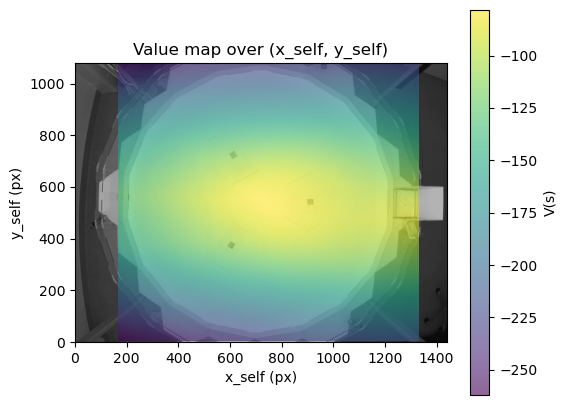

In [ ]:
# """Evaluate V(s) over a 2D grid of positions"""

# # Convert saved normalisation tensors to numpy
# s_mean_np = s_mean.cpu().numpy()
# s_std_np  = s_std.cpu().numpy()

# # Define arena resolution
# nx, ny = 200, 200  # grid resolution

# # Arena bounds from data (unchanged)
# x_min, x_max = state_df["x_self"].min(), state_df["x_self"].max()
# y_min, y_max = state_df["y_self"].min(), state_df["y_self"].max()

# # Build grid
# xs = np.linspace(x_min, x_max, nx)
# ys = np.linspace(y_min, y_max, ny)
# xx, yy = np.meshgrid(xs, ys)

# # Build full state vectors (x_self, y_self, vx_self, vy_self, dx, dy, dvx, dvy)
# s_grid = np.zeros((nx * ny, 8), dtype="float32")
# s_grid[:, 0] = xx.ravel()
# s_grid[:, 1] = yy.ravel()

# # Normalise exactly like training
# s_grid_norm = (s_grid - s_mean_np) / s_std_np

# # Convert to torch
# s_tensor = torch.from_numpy(s_grid_norm).to(device)

# # Evaluate V
# value_net.eval()
# with torch.no_grad():
#     v_vals = value_net(s_tensor).cpu().numpy().reshape(ny, nx)

# # Plot
# plt.figure(figsize=(6, 5))

# arena_img = plt.imread("arena.png")
# img_h, img_w = arena_img.shape[:2]

# # Plot image in its own pixel coordinates: x ∈ [0, img_w], y ∈ [0, img_h]
# plt.imshow(
#     arena_img,
#     origin="lower"
# )

# # Overlay V(s) in its ORIGINAL coordinate system
# plt.imshow(
#     v_vals,
#     origin="lower",
#     extent=[x_min, x_max, y_min, y_max],
#     cmap="viridis",
#     alpha=0.6
# )

# # Clamp axes to image bounds so anything outside is clipped/ignored
# plt.xlim(0, img_w)
# plt.ylim(0, img_h)
# plt.gca().set_aspect("equal", "box")

# plt.colorbar(label="V(s)")
# plt.title("Value map over (x_self, y_self)")
# plt.xlabel("x_self (px)")
# plt.ylabel("y_self (px)")
# plt.show()


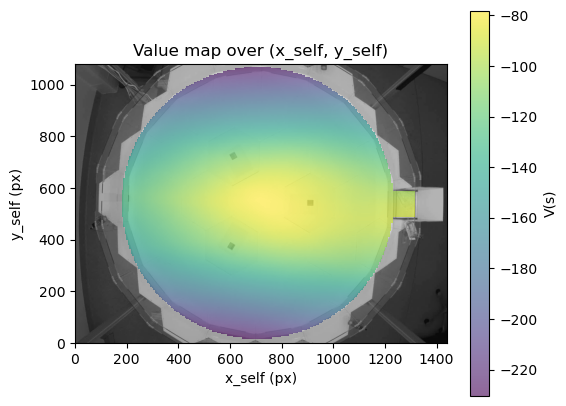

In [ ]:
"""Evaluate V(s) over a 2D grid of positions""" 

# TODO: figure out why boundary between corridor and centre is weird + move imports

from aeon.schema.schemas import social02
from swc.aeon.io import api as aeon_api

exp, acquisition_computer = experiment["name"].split('-', 1)
acquisition_computer = acquisition_computer.upper()
root_path = f"/ceph/aeon/aeon/data/raw/{acquisition_computer}/{exp}"
metadata_reader = social02.Metadata
metadata = aeon_api.load(root_path, metadata_reader)['metadata'].iloc[0]
inner_radius = float(metadata.ActiveRegion.ArenaInnerRadius)
outer_radius = float(metadata.ActiveRegion.ArenaOuterRadius)
center_x = float(metadata.ActiveRegion.ArenaCenter.X)
center_y = float(metadata.ActiveRegion.ArenaCenter.Y)
nest_corner_1 = metadata.ActiveRegion.NestRegion.ArrayOfPoint[0]
nest_corner_2 = metadata.ActiveRegion.NestRegion.ArrayOfPoint[1]
nest_corner_3 = metadata.ActiveRegion.NestRegion.ArrayOfPoint[2]
nest_corner_4 = metadata.ActiveRegion.NestRegion.ArrayOfPoint[3]
print(f"Arena center: ({center_x}, {center_y}), inner radius: {inner_radius}, outer radius: {outer_radius}")
print(f"Nest region corners: {nest_corner_1}, {nest_corner_2}, {nest_corner_3}, {nest_corner_4}")

# Toggle which regions to plot
corridor = True
nest_region = True
arena_centre = True

# Convert saved normalisation tensors to numpy
s_mean_np = s_mean.cpu().numpy()
s_std_np = s_std.cpu().numpy()

# Define arena resolution
nx, ny = 200, 200  # grid resolution

# Arena bounds from data (unchanged)
x_min, x_max = state_df["x_self"].min(), state_df["x_self"].max()
y_min, y_max = state_df["y_self"].min(), state_df["y_self"].max()

# Build grid
xs = np.linspace(x_min, x_max, nx)
ys = np.linspace(y_min, y_max, ny)
xx, yy = np.meshgrid(xs, ys)

# Build full state vectors (x_self, y_self, vx_self, vy_self, dx, dy, dvx, dvy)
s_grid = np.zeros((nx * ny, 8), dtype="float32")
s_grid[:, 0] = xx.ravel()
s_grid[:, 1] = yy.ravel()

# Normalise exactly like training
s_grid_norm = (s_grid - s_mean_np) / s_std_np

# Convert to torch
s_tensor = torch.from_numpy(s_grid_norm).to(device)

# Evaluate V
value_net.eval()
with torch.no_grad():
    v_vals = value_net(s_tensor).cpu().numpy().reshape(ny, nx)

# ------------------------------------------------------------------
# Build masks for the different regions

# Distance from arena center
dx = xx - center_x
dy = yy - center_y
r = np.sqrt(dx**2 + dy**2)

# Corridor: between inner_radius and outer_radius
mask_corridor = (r >= inner_radius) & (r <= outer_radius)

# Arena centre: from centre to inner_radius
mask_arena_centre = (r <= inner_radius)

# Nest rectangle bounds
nest_xs = np.array([
    float(nest_corner_1.X),
    float(nest_corner_2.X),
    float(nest_corner_3.X),
    float(nest_corner_4.X),
], dtype=float)
nest_ys = np.array([
    float(nest_corner_1.Y),
    float(nest_corner_2.Y),
    float(nest_corner_3.Y),
    float(nest_corner_4.Y),
], dtype=float)

nest_x_min, nest_x_max = nest_xs.min(), nest_xs.max()
nest_y_min, nest_y_max = nest_ys.min(), nest_ys.max()

mask_nest = (
    (xx >= nest_x_min) & (xx <= nest_x_max) &
    (yy >= nest_y_min) & (yy <= nest_y_max)
)

# Combine according to toggles
valid_mask = np.zeros_like(v_vals, dtype=bool)
if corridor:
    valid_mask |= mask_corridor
if nest_region:
    valid_mask |= mask_nest
if arena_centre:
    valid_mask |= mask_arena_centre

# Set invalid points to NaN so imshow won't draw them
v_vals_masked = np.where(valid_mask, v_vals, np.nan)
# ------------------------------------------------------------------

# Plot
plt.figure(figsize=(6, 5))

arena_img = plt.imread("arena.png")
img_h, img_w = arena_img.shape[:2]

# Image in its own pixel coordinates
plt.imshow(
    arena_img,
    origin="lower"
)

# Overlay masked V(s) in ORIGINAL coordinate system
plt.imshow(
    v_vals_masked,
    origin="lower",
    extent=[x_min, x_max, y_min, y_max],
    cmap="viridis",
    alpha=0.6
)

# Clip to image bounds
plt.xlim(0, img_w)
plt.ylim(0, img_h)
plt.gca().set_aspect("equal", "box")

plt.colorbar(label="V(s)")
plt.title("Value map over (x_self, y_self)")
plt.xlabel("x_self (px)")
plt.ylabel("y_self (px)")
plt.show()